In [4]:
from fileIO import *
from constants import *
import numpy as np
import matplotlib.pyplot as plt

"""
Import 2D cuDisc run (steadyTD.cpp)
"""

sim = CuDiscModel("../outputs/isoPD2D_test")

# Load in grids, densities and temperatures

g = sim.grid
sizes = sim.load_grain_sizes()
gas, dust = sim.load_all_prim_data()
temp = sim.load_all_temp_data()
#opacs = sim.load_opacity()
ts = sim.load_output_times()

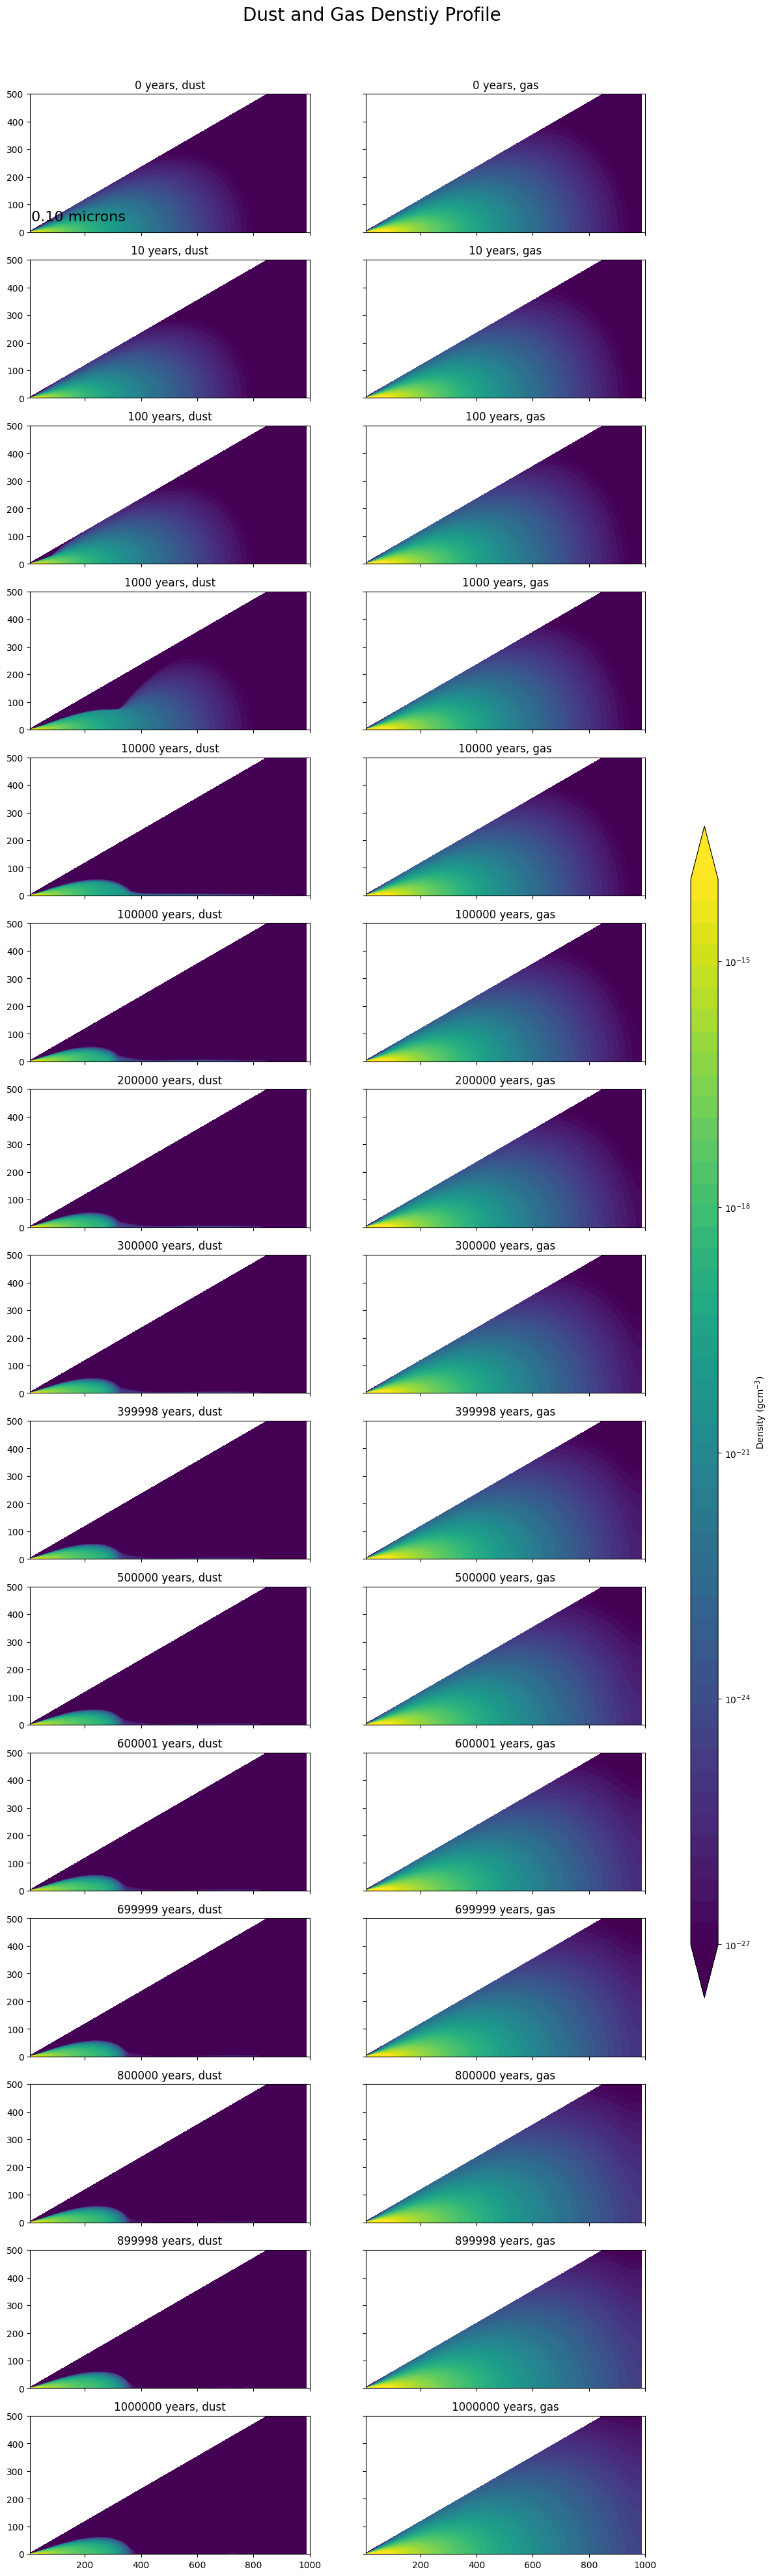

In [31]:
tsnaps = [i for i in range(0, len(ts))]
grain = 0

fig, ax = plt.subplots(len(ts), 2, figsize=(14, 3*np.size(tsnaps)), sharex=True, sharey=True)

for i in range(0, len(ts)):
    cond = ax[i,0].contourf(g.R/au, g.Z/au, np.log10(dust.rho[i,:,:,0]), np.linspace(-27,-14,50), extend='both')
    ax[i,0].set_title('%1.0d years, dust'%(ts[i]//year))
    cong = ax[i,1].contourf(g.R/au, g.Z/au, np.log10(gas.rho[i,:,:]), np.linspace(-27,-14,50), extend='both')
    ax[i,1].set_title('%1.0d years, gas'%(ts[i]//year))

ax[0,0].text(10,40, "%1.2f microns"%(sizes.a_c[grain]*1e4), fontsize=16, c='k')

plt.xlim(5,1000)
plt.ylim(0,500)
fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.3, 0.03, 0.4])
cbar = fig.colorbar(cond, cax=cbar_ax)
cbar.set_ticks(np.arange(-27,-12,3))
cbar.set_ticklabels(["$10^{%d}$"%(x) for x in np.arange(-27,-12,3)])
cbar.set_label(r"Density (gcm$^{-3}$)")
fig.subplots_adjust(top=0.95)
fig.suptitle("Dust and Gas Denstiy Profile", size=20)

plt.show()

2.1156450669644855e-07 1.365012107021944e+41


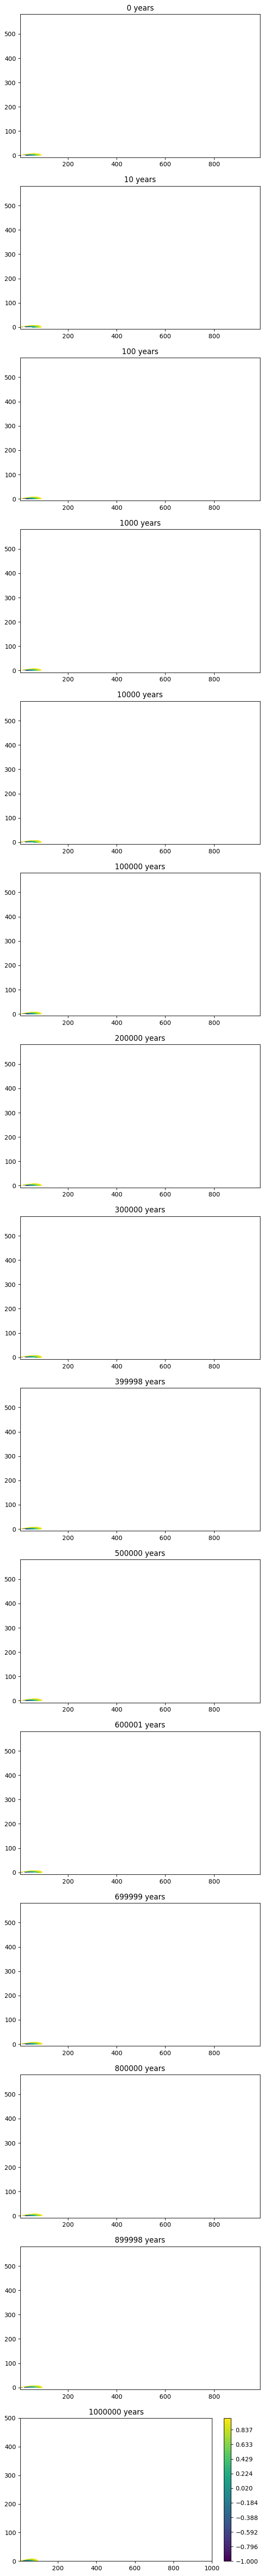

In [32]:
grain_radius = 1e-1
mu = 2.4
internal_density = 1.6

def find_cs2(temp):
    return k_B * temp.T[0,:,:] / (mu * m_H)

def stokes(g, dust, gas, temp):
    cs = np.sqrt(find_cs2(temp))[None,:,:,None]
    Omega = np.sqrt(GMsun / g.R_c) /g.R_c
    rho_g = gas.rho[:,:,:,None]
    u_rel = np.sqrt((dust.vR - gas.vR[:,:,:,None])**2 + (dust.vphi - gas.vphi[:,:,:,None])**2 + (dust.vZ - gas.vZ[:,:,:,None])**2)
    mfp = mu * m_H / (rho_g * 2e-15)
    sqrtgamma = np.sqrt(1.0 + 0.4 * mu)
    nu_mol = 1.595769122 * 0.5 * mfp * cs
    Re = 2.0 * grain_radius * u_rel / nu_mol
    M = u_rel / cs
    G = (10.0 ** (2.5 * ((Re / 312)**0.6688))) / ((1 + ((Re / 312)**0.6688)))
    H = 4.6 / (1.0 + M) + 1.7
    vC_inc = 12.0 * nu_mol / grain_radius * (1.0 + 0.15 * (Re ** 0.687) + 0.407 * u_rel * Re / (Re + 8710))
    vC_D = 2 * u_rel + (vC_inc - 2 * u_rel) * np.exp(-1.535 *sqrtgamma * G * nu_mol / (grain_radius * cs)) + H * np.exp(-grain_radius * cs / nu_mol) * cs / sqrtgamma
    return 8 * internal_density * grain_radius * Omega / (3 * rho_g * vC_D)

St = stokes(g, dust, gas, temp)

fig, ax = plt.subplots(len(tsnaps), 1, figsize=(7, 5*len(tsnaps)))

for i in range(len(tsnaps)):
    con = ax[i].contourf(g.R/au, g.Z/au, np.log10(St[tsnaps[i],:,:,0]), np.linspace(-1, 1, 50))
    ax[i].set_title('%1.0d years'%(ts[tsnaps[i]]//year))

print(np.min(St), np.max(St))

plt.ylim(0,500)
plt.xlim(5,1000)
plt.colorbar(con)
plt.show()

/tmp/ipykernel_500552/3063818192.py:7: RuntimeWarning: divide by zero encountered in log10
  con = ax[i,0].contourf(g.R/au, g.Z/au, np.log10(np.abs(dust.vR[i,:,:,0])), vel_range, extend='both')
/tmp/ipykernel_500552/3063818192.py:11: RuntimeWarning: divide by zero encountered in log10
  ax[i,1].contourf(g.R/au, g.Z/au, np.log10(np.abs(dust.vZ[i,:,:,0])), vel_range, extend='both')
/tmp/ipykernel_500552/3063818192.py:15: RuntimeWarning: divide by zero encountered in log10
  ax[i,2].contourf(g.R/au, g.Z/au, np.log10(speed[i,:,:,0]), vel_range, extend='both')


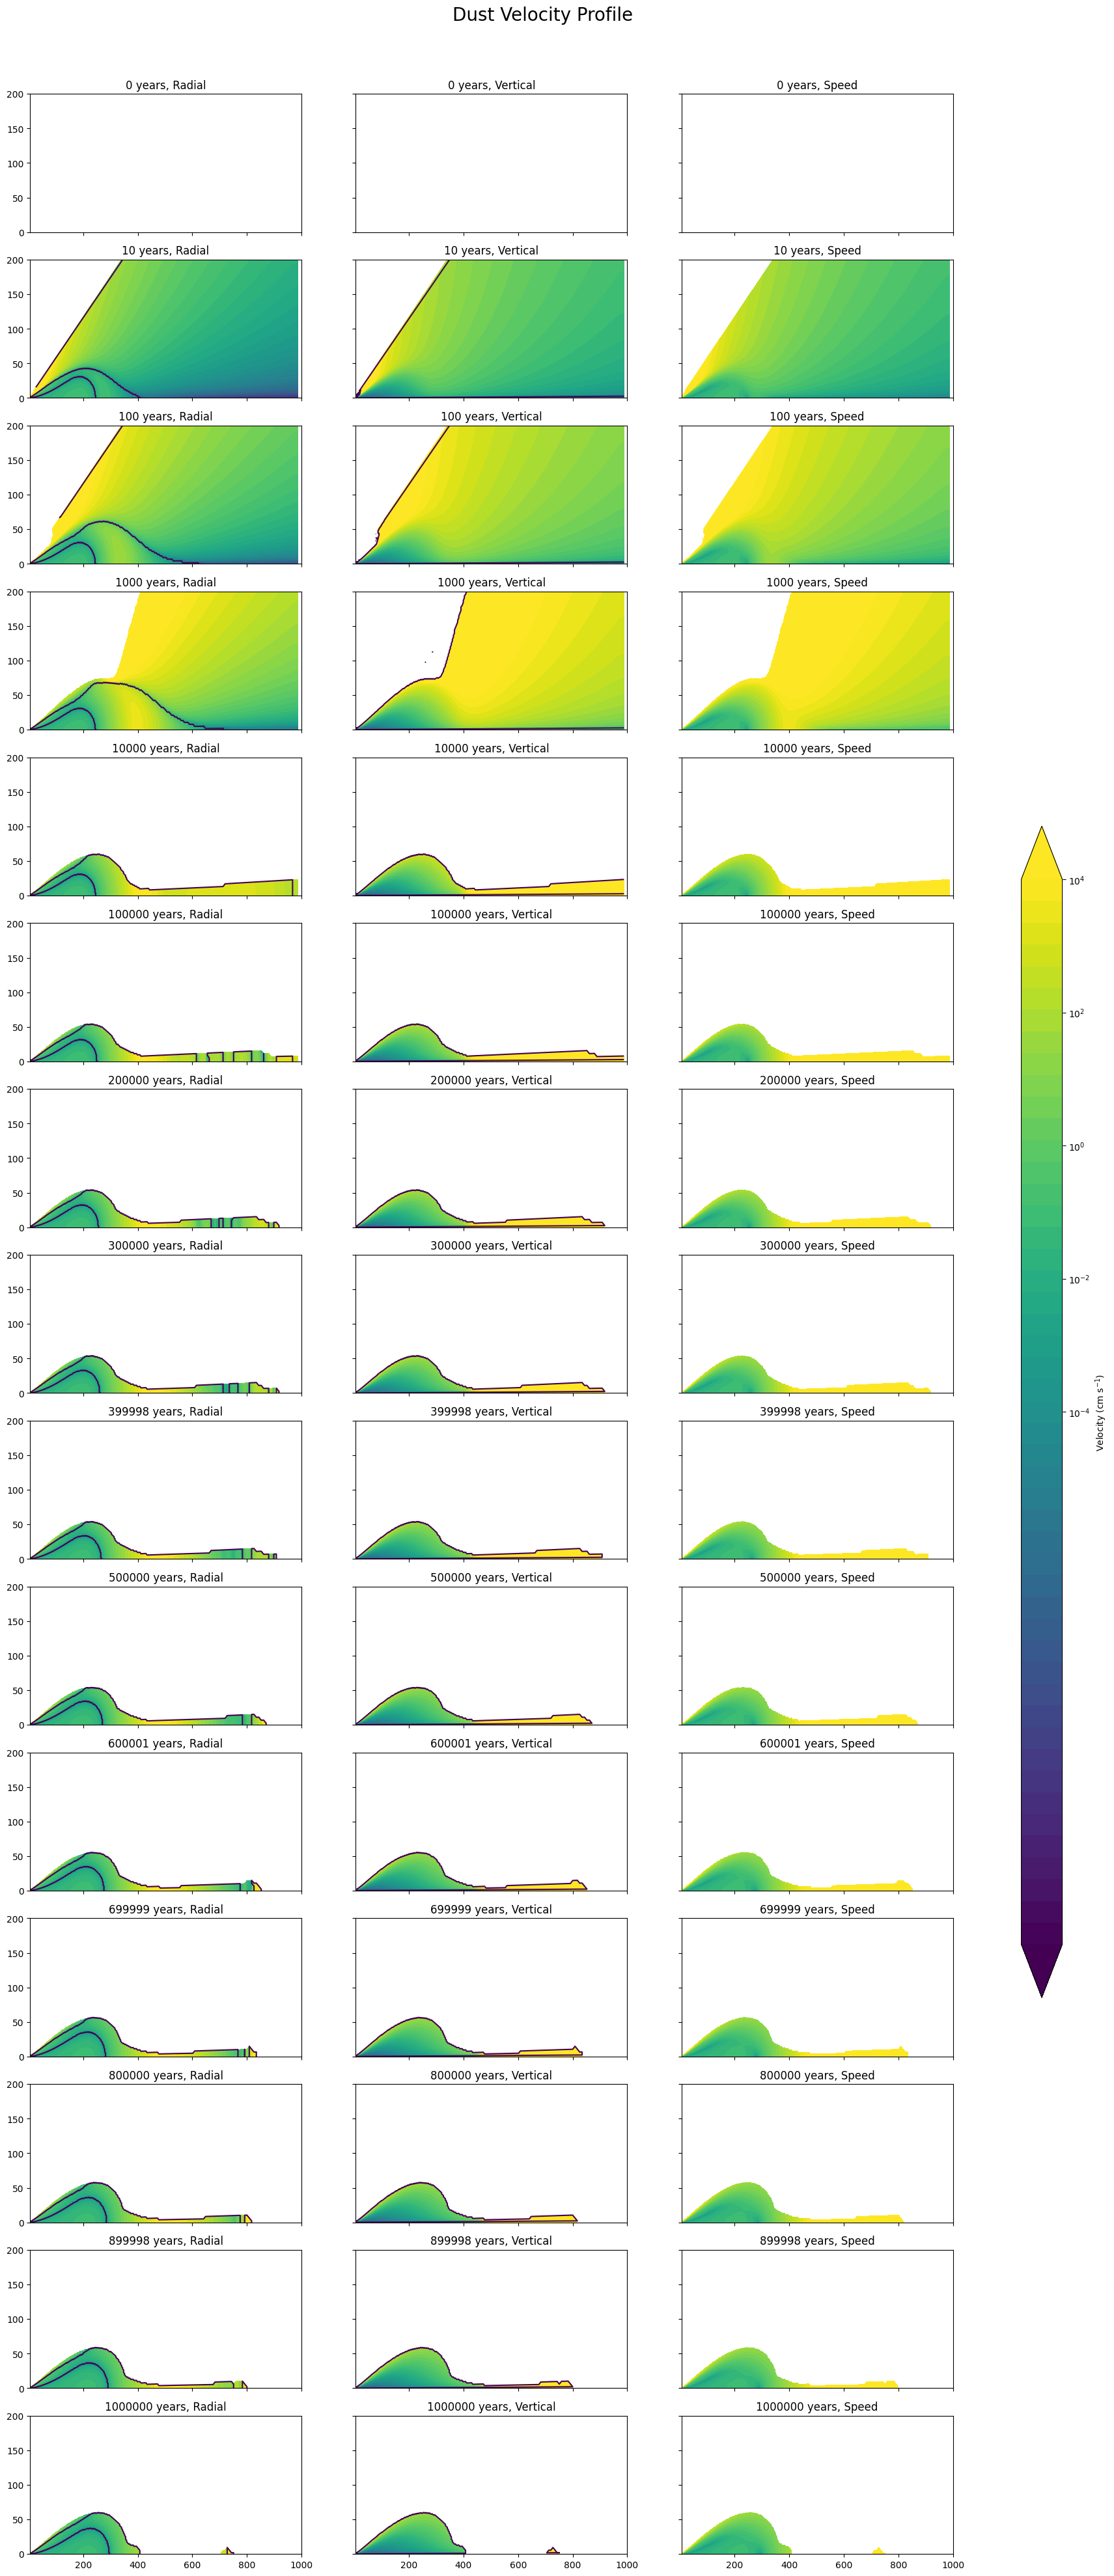

/tmp/ipykernel_500552/3063818192.py:35: RuntimeWarning: divide by zero encountered in log10
  con = ax[i,0].contourf(g.R/au, g.Z/au, np.log10(np.abs(gas.vR[i,:,:])), vel_range, extend='both')
/tmp/ipykernel_500552/3063818192.py:39: RuntimeWarning: divide by zero encountered in log10
  ax[i,1].contourf(g.R/au, g.Z/au, np.log10(np.abs(gas.vZ[i,:,:])), vel_range, extend='both')
/tmp/ipykernel_500552/3063818192.py:43: RuntimeWarning: divide by zero encountered in log10
  ax[i,2].contourf(g.R/au, g.Z/au, np.log10(speed[i,:,:]), vel_range, extend='both')


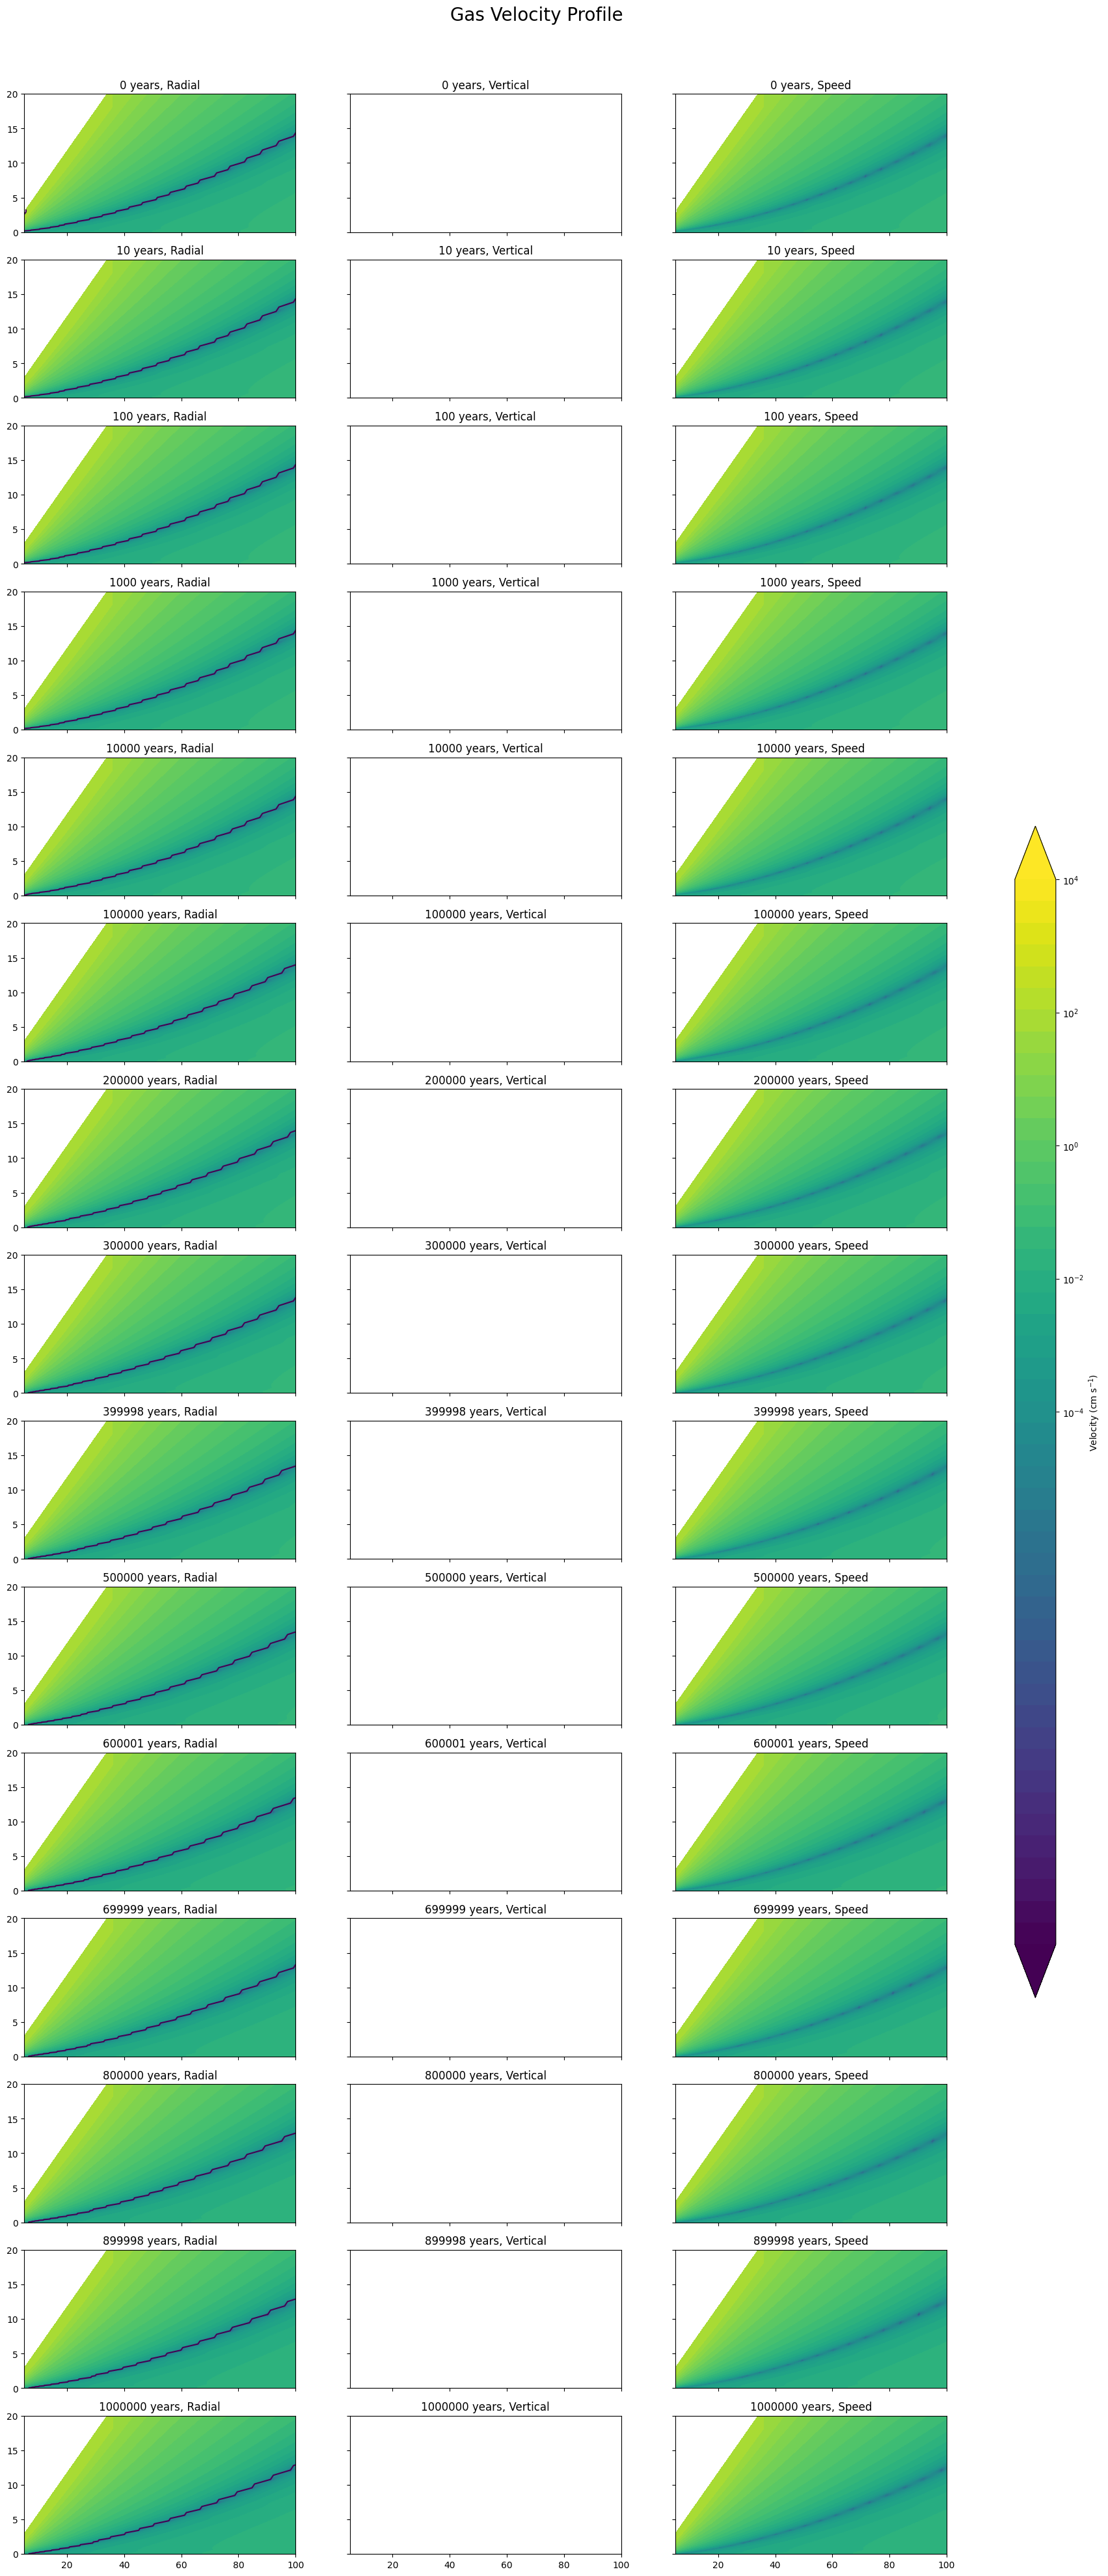

In [33]:
fig, ax = plt.subplots(len(ts), 3, figsize=(21, 3*np.size(tsnaps)), sharex=True, sharey=True)
speed = np.sqrt(dust.vZ**2 + dust.vR**2)

vel_range = np.linspace(-4,4,50)

for i in range(0, len(ts)):
    con = ax[i,0].contourf(g.R/au, g.Z/au, np.log10(np.abs(dust.vR[i,:,:,0])), vel_range, extend='both')
    ax[i,0].contour(g.R/au, g.Z/au, np.sign(dust.vR[i,:,:,0]), np.array([-1,1]))
    ax[i,0].set_title('%1.0d years, Radial'%(ts[i]//year))

    ax[i,1].contourf(g.R/au, g.Z/au, np.log10(np.abs(dust.vZ[i,:,:,0])), vel_range, extend='both')
    ax[i,1].contour(g.R/au, g.Z/au, np.sign(dust.vZ[i,:,:,0]), np.array([-1,1]))
    ax[i,1].set_title('%1.0d years, Vertical'%(ts[i]//year))

    ax[i,2].contourf(g.R/au, g.Z/au, np.log10(speed[i,:,:,0]), vel_range, extend='both')
    ax[i,2].set_title('%1.0d years, Speed'%(ts[i]//year))

plt.xlim(5,1000)
plt.ylim(0,200)
fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.3, 0.03, 0.4])
cbar = fig.colorbar(con, cax=cbar_ax)
cbar.set_ticks(np.linspace(0,4,num=5))
cbar.set_ticklabels(["$10^{%d}$"%(x) for x in np.linspace(-4,4,num=5)])
cbar.set_label(r"Velocity (cm s$^{-1}$)")
fig.subplots_adjust(top=0.95)
fig.suptitle("Dust Velocity Profile", size=20)

plt.show()

fig, ax = plt.subplots(len(ts), 3, figsize=(21, 3*np.size(tsnaps)), sharex=True, sharey=True)
speed = np.sqrt(gas.vZ**2 + gas.vR**2)

for i in range(0, len(ts)):
    con = ax[i,0].contourf(g.R/au, g.Z/au, np.log10(np.abs(gas.vR[i,:,:])), vel_range, extend='both')
    ax[i,0].contour(g.R/au, g.Z/au, np.sign(gas.vR[i,:,:]), np.array([-1,1]))
    ax[i,0].set_title('%1.0d years, Radial'%(ts[i]//year))

    ax[i,1].contourf(g.R/au, g.Z/au, np.log10(np.abs(gas.vZ[i,:,:])), vel_range, extend='both')
    ax[i,1].contour(g.R/au, g.Z/au, np.sign(gas.vZ[i,:,:]), np.array([-1,1]))
    ax[i,1].set_title('%1.0d years, Vertical'%(ts[i]//year))

    ax[i,2].contourf(g.R/au, g.Z/au, np.log10(speed[i,:,:]), vel_range, extend='both')
    ax[i,2].set_title('%1.0d years, Speed'%(ts[i]//year))

plt.xlim(5,100)
plt.ylim(0,20)
fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.3, 0.03, 0.4])
cbar = fig.colorbar(con, cax=cbar_ax)
cbar.set_ticks(np.linspace(0,4,num=5))
cbar.set_ticklabels(["$10^{%d}$"%(x) for x in np.linspace(-4,4,num=5)])
cbar.set_label(r"Velocity (cm s$^{-1}$)")
fig.subplots_adjust(top=0.95)
fig.suptitle("Gas Velocity Profile", size=20)

plt.show()

In [6]:
M = abs(np.max(gas.vphi))
print(M)

for i in range(504):
    for j in range(54):
        for t in range(11):
            if abs(gas.vphi[t,i,j]) == M:
                print(ts[t]/year, g.R[i,j]/au, g.Z[i,j]/au)

10718438.219716525
1.0 6.076790455579664 1.7310706055688958
